Осипов Тимофей Максимович, Р3124

Первые 10 строк обучающей выборки:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



Типы данных в обучающей выборке:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Количество пропусков в обучающей выборке:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Статистика числовых признаков:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


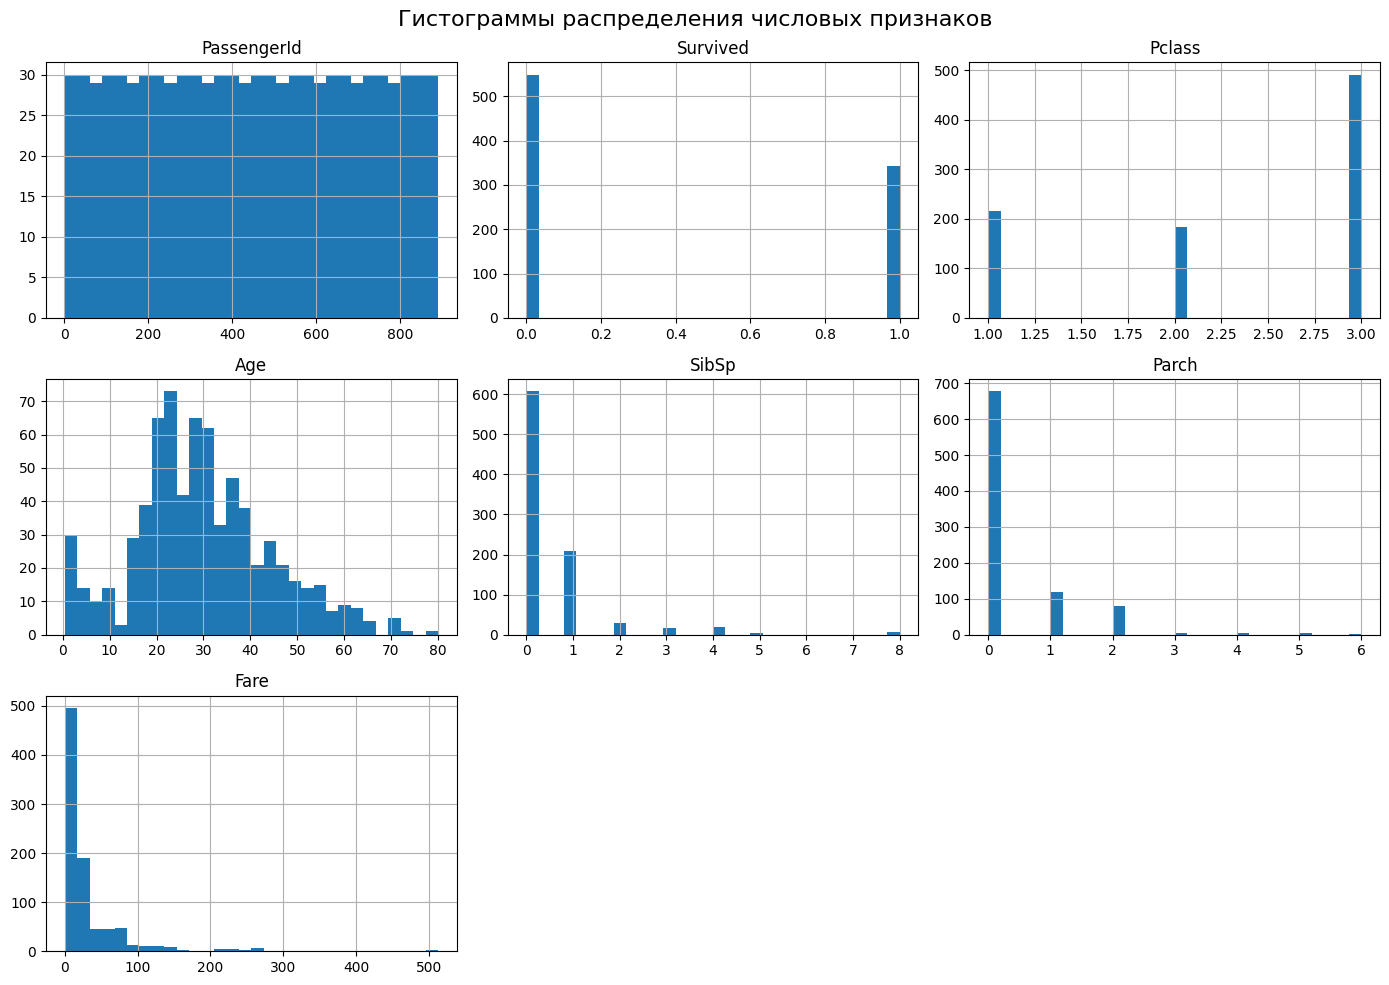

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Отключаем предупреждения
import warnings
warnings.filterwarnings('ignore')

# 1. Загружаем данные
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission_df = pd.read_csv('gender_submission.csv')

# 2. Первые 10 строк
print("Первые 10 строк обучающей выборки:")
display(train_df.head(10))

# 3. Типы данных
print("\nТипы данных в обучающей выборке:")
display(train_df.dtypes)

# 4. Количество пропусков
print("\nКоличество пропусков в обучающей выборке:")
display(train_df.isnull().sum())

# 5. Статистика числовых признаков
print("\nСтатистика числовых признаков:")
display(train_df.describe())

# 6. Гистограммы числовых признаков
train_df.hist(figsize=(14, 10), bins=30)
plt.suptitle('Гистограммы распределения числовых признаков', size=16)
plt.tight_layout()
plt.show()

In [3]:
# 2. Обработка пропусков
print("Пропуски до обработки:")
display(train_df.isnull().sum())

# 2.1 Age — заполняем медианой
median_age = train_df['Age'].median()
train_df['Age'].fillna(median_age, inplace=True)
print(f"Пропуски в Age после заполнения: {train_df['Age'].isnull().sum()}")

# 2.2 Создаём Age_group на основе возраста
bins = [0, 12, 18, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle', 'Senior']
train_df['Age_group'] = pd.cut(train_df['Age'], bins=bins, labels=labels)
print("Распределение по возрастным группам:")
display(train_df['Age_group'].value_counts().sort_index())

# 2.3 Embarked — заполняем модой
mode_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Пропуски в Embarked после заполнения: {train_df['Embarked'].isnull().sum()}")
print(f"Мода Embarked: {mode_embarked}")

# 2.4 Cabin — создаём новый признак Cabin_letter
train_df['Cabin_letter'] = train_df['Cabin'].astype(str).str[0]
train_df['Cabin_letter'] = train_df['Cabin_letter'].replace('n', 'Unknown')
print("Распределение по буквам кают:")
display(train_df['Cabin_letter'].value_counts())

# Проверяем на пропуски
print("\nПропуски после обработки:")
display(train_df.isnull().sum())

Пропуски до обработки:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Пропуски в Age после заполнения: 0
Распределение по возрастным группам:


,count
Age_group,
Child,69
Teen,70
Adult,602
Middle,128
Senior,22


Пропуски в Embarked после заполнения: 0
Мода Embarked: S
Распределение по буквам кают:


,count
Cabin_letter,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1



Пропуски после обработки:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
# 3. Работа с типами данных

# 3.1 Pclass → категориальный (F, S, T)
train_df['Pclass'] = train_df['Pclass'].map({1: 'F', 2: 'S', 3: 'T'})
print("Распределение Pclass после преобразования:")
display(train_df['Pclass'].value_counts())

# 3.2 Title из Name
train_df['Title'] = train_df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
print("Распределение титулов:")
display(train_df['Title'].value_counts())

# 3.3 Sex → числовой
train_df['Sex_binary'] = train_df['Sex'].map({'male': 0, 'female': 1})
print("Распределение Sex_binary:")
display(train_df['Sex_binary'].value_counts())

# 3.4 FamilySize = SibSp + Parch + 1
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# 3.5 IsAlone (1 если FamilySize = 1, иначе 0)
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
print("Распределение IsAlone:")
display(train_df['IsAlone'].value_counts())

# Проверяем новые признаки
print("\nПервые 5 строк с новыми признаками:")
display(train_df[['Name', 'Title', 'Pclass', 'Sex_binary', 'FamilySize', 'IsAlone']].head())

Распределение Pclass после преобразования:


,count
Pclass,
T,491
F,216
S,184


Распределение титулов:


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Распределение Sex_binary:


,count
Sex_binary,
0,577
1,314


Распределение IsAlone:


,count
IsAlone,
1,537
0,354



Первые 5 строк с новыми признаками:


,Name,Title,Pclass,Sex_binary,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,T,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,F,1,2,0
2,"Heikkinen, Miss. Laina",Miss,T,1,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,F,1,2,0
4,"Allen, Mr. William Henry",Mr,T,0,1,1


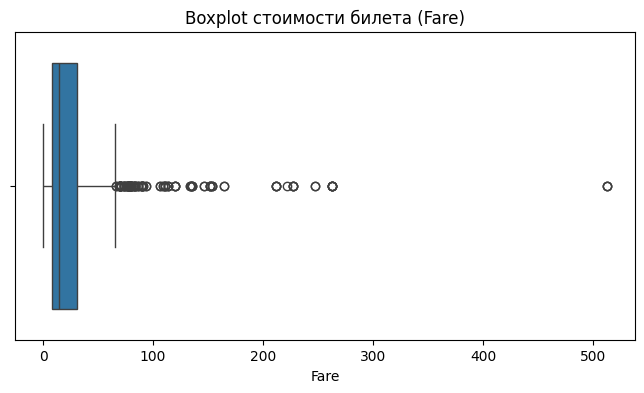

Границы Fare: -26.72 – 65.63
Количество выбросов в Fare: 116
Максимальное значение после winsorization: 112.08


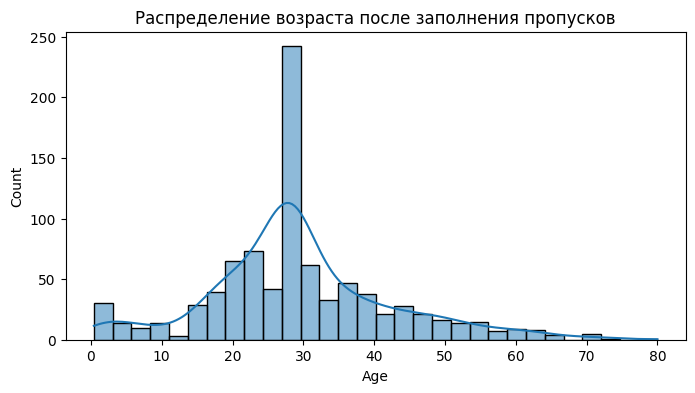

Максимальный возраст после winsorization: 54.00


In [5]:
# 4. Удаление выбросов

# 4.1 Boxplot для Fare
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df['Fare'])
plt.title('Boxplot стоимости билета (Fare)')
plt.show()

# 4.2 IQR для Fare
Q1_fare = train_df['Fare'].quantile(0.25)
Q3_fare = train_df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
print(f"Границы Fare: {lower_fare:.2f} – {upper_fare:.2f}")
print(f"Количество выбросов в Fare: {((train_df['Fare'] < lower_fare) | (train_df['Fare'] > upper_fare)).sum()}")

# 4.3 Winsorization для Fare (95-й перцентиль)
fare_95 = train_df['Fare'].quantile(0.95)
train_df['Fare_winsor'] = train_df['Fare'].clip(upper=fare_95)
print(f"Максимальное значение после winsorization: {train_df['Fare_winsor'].max():.2f}")

# 4.4 Визуализация распределения Age
plt.figure(figsize=(8, 4))
sns.histplot(train_df['Age'], bins=30, kde=True)
plt.title('Распределение возраста после заполнения пропусков')
plt.show()

# 4.5 Winsorization для Age (95-й перцентиль)
age_95 = train_df['Age'].quantile(0.95)
train_df['Age_winsor'] = train_df['Age'].clip(upper=age_95)
print(f"Максимальный возраст после winsorization: {train_df['Age_winsor'].max():.2f}")

In [6]:
# 5. Агрегация данных

# 5.1 Среднее выживание по классам
print("Среднее выживание по классам:")
display(train_df.groupby('Pclass')['Survived'].mean())

# 5.2 Группировка по Pclass и Sex
print("Среднее выживание по классам и полу:")
display(train_df.groupby(['Pclass', 'Sex'])['Survived'].mean())

# 5.3 Медианный возраст по портам посадки
print("Медианный возраст по портам посадки:")
display(train_df.groupby('Embarked')['Age'].median())

# 5.4 Сводная таблица выживаемости
pivot_table = pd.pivot_table(train_df,
                             values='Survived',
                             index='Pclass',
                             columns='Sex_binary',
                             aggfunc='mean')
print("Сводная таблица выживаемости (Pclass / Sex):")
display(pivot_table)

# 5.5 Дополнительная сводная по Age_group и Pclass
pivot_age = pd.pivot_table(train_df,
                           values='Survived',
                           index='Age_group',
                           columns='Pclass',
                           aggfunc='mean')
print("Сводная таблица выживаемости (Age_group / Pclass):")
display(pivot_age)

Среднее выживание по классам:


,Survived
Pclass,
F,0.629630
S,0.472826
T,0.242363


Среднее выживание по классам и полу:


Pclass  Sex   
F       female    0.968085
        male      0.368852
S       female    0.921053
        male      0.157407
T       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

Медианный возраст по портам посадки:


,Age
Embarked,
C,28.0
Q,28.0
S,28.0


Сводная таблица выживаемости (Pclass / Sex):


Sex_binary,0,1
Pclass,,
F,0.368852,0.968085
S,0.157407,0.921053
T,0.135447,0.500000


Сводная таблица выживаемости (Age_group / Pclass):


Pclass,F,S,T
Age_group,,,
Child,0.750000,1.000000,0.416667
Teen,0.916667,0.500000,0.282609
Adult,0.669355,0.421488,0.232493
Middle,0.580645,0.387097,0.057143
Senior,0.214286,0.333333,0.200000


Процент заполненных значений по столбцам:


,0
PassengerId,100.000000
Survived,100.000000
Pclass,100.000000
Name,100.000000
Sex,100.000000
Age,100.000000
SibSp,100.000000
Parch,100.000000
Ticket,100.000000
Fare,100.000000


Количество уникальных значений в категориальных признаках:
Pclass: 3
Sex: 2
Embarked: 3
Age_group: 5
Title: 17
Cabin_letter: 9

Распределение Age_group:


,count
Age_group,
Child,69
Teen,70
Adult,602
Middle,128
Senior,22


Корреляционная матрица новых признаков:


,FamilySize,IsAlone,Age,Fare_winsor,Sex_binary
FamilySize,1.000000,-0.690922,-0.245619,0.305264,0.200988
IsAlone,-0.690922,1.000000,0.171647,-0.395974,-0.303646
Age,-0.245619,0.171647,1.000000,0.132714,-0.081163
Fare_winsor,0.305264,-0.395974,0.132714,1.000000,0.239112
Sex_binary,0.200988,-0.303646,-0.081163,0.239112,1.000000


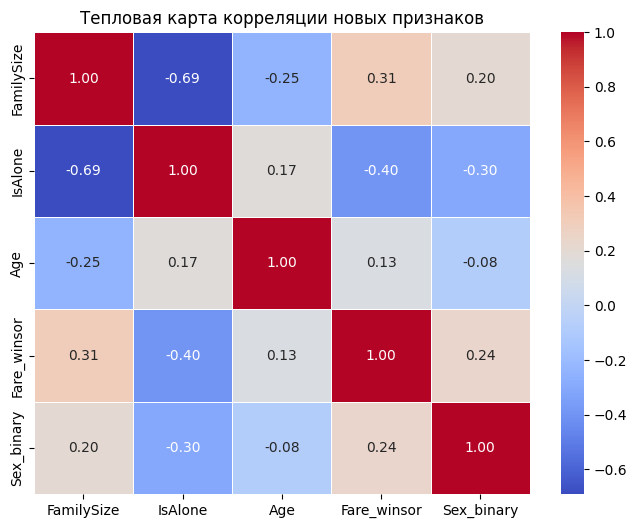

In [7]:
# 6. Метрики качества очистки

# 6.1 Процент заполненных пропусков
filled_percent = (1 - train_df.isnull().sum() / len(train_df)) * 100
print("Процент заполненных значений по столбцам:")
display(filled_percent)

# 6.2 Количество уникальных значений в признаках
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Age_group', 'Title', 'Cabin_letter']
print("Количество уникальных значений в категориальных признаках:")
for col in cat_cols:
    print(f"{col}: {train_df[col].nunique()}")

# 6.3 Распределение значений после трансформации
print("\nРаспределение Age_group:")
display(train_df['Age_group'].value_counts().sort_index())

# 6.4 Корреляция между новыми признаками
new_features = ['FamilySize', 'IsAlone', 'Age', 'Fare_winsor', 'Sex_binary']
correlation_matrix = train_df[new_features].corr()
print("Корреляционная матрица новых признаков:")
display(correlation_matrix)

# 6.5 Тепловая карта корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляции новых признаков')
plt.show()

In [8]:
# 7. Сохраняем очищенные данные
train_df.to_csv('train_cleaned.csv', index=False)
print("Очищенные данные сохранены в 'train_cleaned.csv'")

# Проверяем итоговую структуру
print("\nИтоговая структура данных:")
display(train_df.info())

Очищенные данные сохранены в 'train_cleaned.csv'

Итоговая структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   891 non-null    int64   
 1   Survived      891 non-null    int64   
 2   Pclass        891 non-null    object  
 3   Name          891 non-null    object  
 4   Sex           891 non-null    object  
 5   Age           891 non-null    float64 
 6   SibSp         891 non-null    int64   
 7   Parch         891 non-null    int64   
 8   Ticket        891 non-null    object  
 9   Fare          891 non-null    float64 
 10  Cabin         204 non-null    object  
 11  Embarked      891 non-null    object  
 12  Age_group     891 non-null    category
 13  Cabin_letter  891 non-null    object  
 14  Title         891 non-null    object  
 15  Sex_binary    891 non-null    int64   
 16  FamilySize    891 non

None